In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [150]:
df_audi = pd.read_csv('../data/raw/audi.csv')
df_bmw = pd.read_csv('../data/raw/bmw.csv')
df_ford = pd.read_csv('../data/raw/ford.csv')
df_hyundi = pd.read_csv('../data/raw/hyundi.csv')
df_merc = pd.read_csv('../data/raw/merc.csv')
df_skoda = pd.read_csv('../data/raw/skoda.csv')
df_toyota = pd.read_csv('../data/raw/toyota.csv')
df_vw = pd.read_csv('../data/raw/vw.csv')
df_vauxhall = pd.read_csv('../data/raw/vauxhall.csv')
df_data = pd.concat([df_audi, df_bmw, df_ford, df_hyundi, df_merc, df_skoda, df_toyota, df_vw, df_vauxhall], ignore_index=True)

In [151]:
df_data.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0


In [152]:
df_data.shape

(99187, 9)

In [153]:
df_data.isna().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [154]:
df_data.describe()

,year,price,mileage,tax,mpg,engineSize
count,99187.000000,99187.000000,99187.000000,99187.000000,99187.000000,99187.000000
mean,2017.087723,16805.347656,23058.914213,120.299838,55.166825,1.663280
std,2.123934,9866.773417,21148.523721,63.150926,16.138522,0.557646
min,1970.000000,450.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,9999.000000,7425.000000,125.000000,47.100000,1.200000
50%,2017.000000,14495.000000,17460.000000,145.000000,54.300000,1.600000
75%,2019.000000,20870.000000,32339.000000,145.000000,62.800000,2.000000
max,2060.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000


In [155]:
# PROBLEM-1 (year column)
# Data quality fix: Filter out unrealistic model years.
# Keeping vehicles manufactured between 1990 and 2025.
df_data = df_data[(df_data["year"] >= 1990) & (df_data["year"] <= 2025)]

In [156]:
# PROBLEM-2 (engineSize = 0)
# Data quality fix: Engine size values equal to zero are invalid.
# Replacing zero values with the median engine size.
df_data.loc[df_data["engineSize"] == 0, "engineSize"] = df_data["engineSize"].median()

In [157]:
# PROBLEM-3 (mpg outliers)
# Outlier handling: MPG contains extreme values.
# Capping MPG at the 99th percentile to reduce the impact of outliers.

mpg_upper = df_data["mpg"].quantile(0.99)
df_data.loc[df_data["mpg"] > mpg_upper, "mpg"] = mpg_upper

In [158]:
df_data.describe()

,year,price,mileage,tax,mpg,engineSize
count,99184.000000,99184.000000,99184.000000,99184.000000,99184.000000,99184.000000
mean,2017.088240,16805.432620,23058.541297,120.296318,54.620677,1.667690
std,2.109018,9866.813678,21148.535002,63.148078,11.519825,0.550776
min,1996.000000,450.000000,1.000000,0.000000,0.300000,0.600000
25%,2016.000000,9999.000000,7424.000000,125.000000,47.100000,1.200000
50%,2017.000000,14495.000000,17460.000000,145.000000,54.300000,1.600000
75%,2019.000000,20870.000000,32337.250000,145.000000,62.800000,2.000000
max,2020.000000,159999.000000,323000.000000,580.000000,85.600000,6.600000


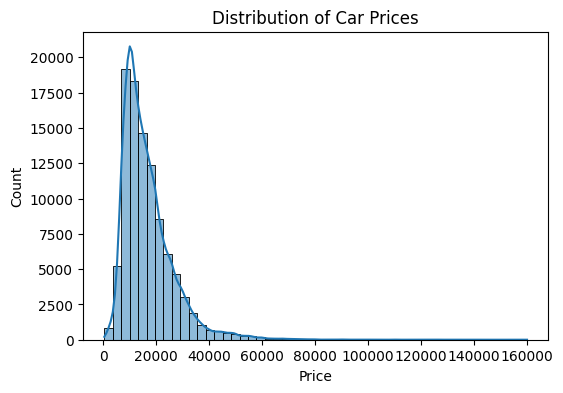

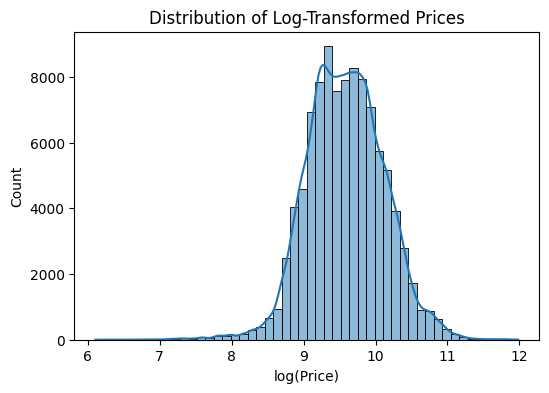

In [159]:
#Price and log-price distribution
plt.figure(figsize=(6,4))
sns.histplot(df_data["price"], bins=50, kde=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(np.log1p(df_data["price"]), bins=50, kde=True)
plt.title("Distribution of Log-Transformed Prices")
plt.xlabel("log(Price)")
plt.ylabel("Count")
plt.show()

The price distribution is highly right-skewed, with a small number of very expensive vehicles.
Applying a logarithmic transformation helps stabilize variance and makes the target distribution
more suitable for regression models.

In [160]:
df_data["age"] = 2025 - df_data["year"]
df_data.drop(columns=["year"], inplace=True)

In [161]:
df_data.head()

,model,price,transmission,mileage,fuelType,tax,mpg,engineSize,age
0,A1,12500,Manual,15735,Petrol,150,55.4,1.4,8
1,A6,16500,Automatic,36203,Diesel,20,64.2,2.0,9
2,A1,11000,Manual,29946,Petrol,30,55.4,1.4,9
3,A4,16800,Automatic,25952,Diesel,145,67.3,2.0,8
4,A3,17300,Manual,1998,Petrol,145,49.6,1.0,6


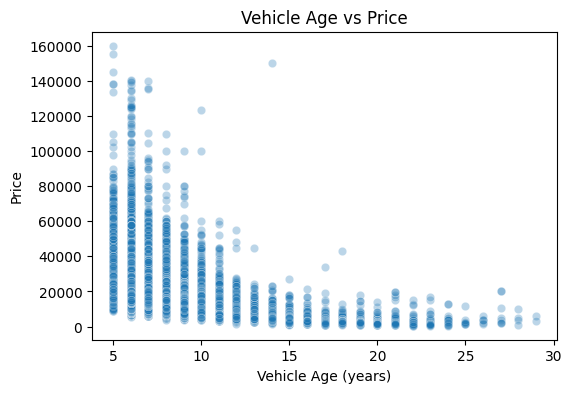

In [162]:
#Vehicle age vs price
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df_data["age"],
    y=df_data["price"],
    alpha=0.3
)
plt.title("Vehicle Age vs Price")
plt.xlabel("Vehicle Age (years)")
plt.ylabel("Price")
plt.show()

There is a clear negative relationship between vehicle age and price.
As vehicles get older, their market value decreases significantly,
making vehicle age one of the most important predictive features.

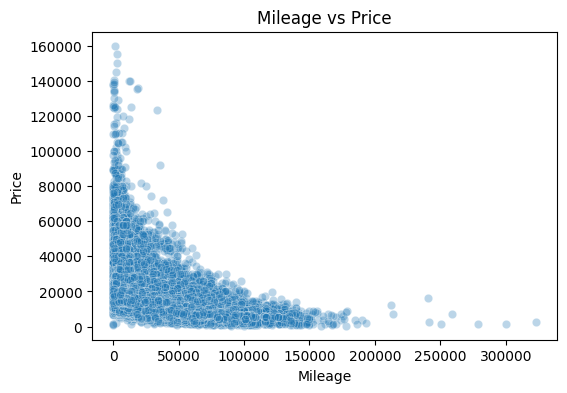

In [163]:
# Mileage vs price
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df_data["mileage"],
    y=df_data["price"],
    alpha=0.3
)
plt.title("Mileage vs Price")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()

Mileage shows a negative correlation with price, although the relationship is noisier
than vehicle age. Higher mileage generally leads to lower prices,
but the impact varies across models and engine types.

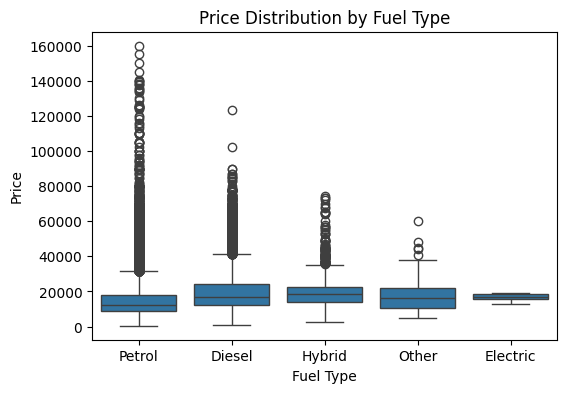

In [164]:
# Fuel type vs price
plt.figure(figsize=(6,4))
sns.boxplot(
    x="fuelType",
    y="price",
    data=df_data
)
plt.title("Price Distribution by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Price")
plt.show()

Fuel type has a noticeable impact on pricing.
Diesel and hybrid vehicles tend to have higher median prices compared to petrol vehicles,
reflecting differences in fuel efficiency and market demand.

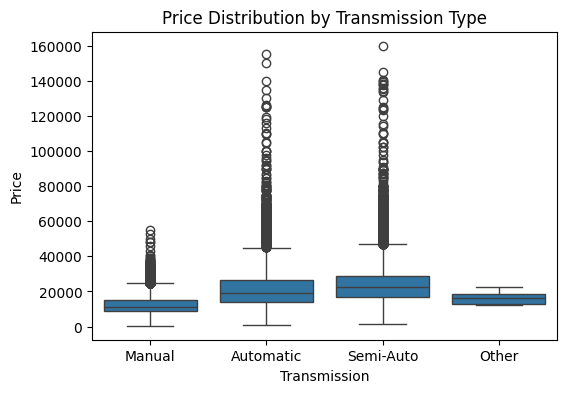

In [165]:
# Transmission vs price
plt.figure(figsize=(6,4))
sns.boxplot(
    x="transmission",
    y="price",
    data=df_data
)
plt.title("Price Distribution by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Price")
plt.show()

Automatic transmission vehicles generally have higher prices than manual ones.
This aligns with market preferences, especially for newer vehicles and premium segments.

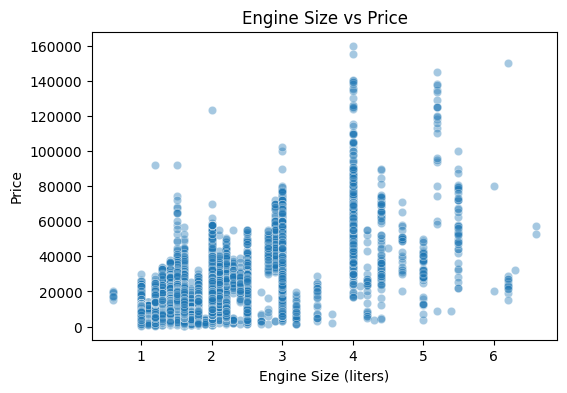

In [166]:
# Engine size vs price
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="engineSize",
    y="price",
    data=df_data,
    alpha=0.4
)
plt.title("Engine Size vs Price")
plt.xlabel("Engine Size (liters)")
plt.ylabel("Price")
plt.show()

Larger engine sizes are generally associated with higher prices.
However, the relationship is not strictly linear, indicating interactions
with other features such as model, fuel type, and transmission.

In [167]:
df_data.to_csv('../data/processed/used_car_data.csv', index=False)